Pipelined Solution

In [12]:
# Penguin Clustering Pipeline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.feature_selection import VarianceThreshold
from sklearn.manifold import TSNE

In [13]:
# --------------------
# 1. Veri Yükleme ve Temizlik
# --------------------
df = pd.read_csv("dataset/penguins.csv")
df = df.dropna()  # Eksik verileri çıkar


In [14]:
# --------------------
# 2. Sayısal Özellikleri Alma ve Aykırı Değer Temizliği (IQR)
# --------------------
numeric_df = df.select_dtypes(include='number')

def remove_outliers_iqr(df):
    Q1 = df.quantile(0.5)
    Q3 = df.quantile(0.95)
    IQR = Q3 - Q1
    mask = ~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)
    return df[mask]

clean_df = remove_outliers_iqr(numeric_df)

In [15]:
# --------------------
# 3. Feature Selection - Düşük Varyanslı Özellikleri At
# --------------------
selector = VarianceThreshold(threshold=0.01)
X_selected = selector.fit_transform(clean_df)

In [16]:
# --------------------
# 4. Ölçekleme (StandardScaler)
# --------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

In [17]:
# --------------------
# 5. PCA ile Boyut Azaltma
# --------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA ile açıklanan varyans oranları:", pca.explained_variance_ratio_)

PCA ile açıklanan varyans oranları: [0.68909175 0.19248704]


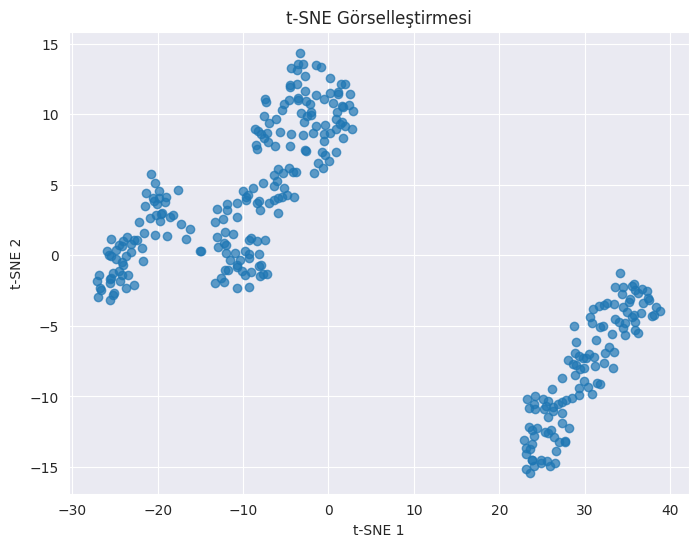

In [18]:
# --------------------
# 6. t-SNE ile Alternatif Görselleştirme
# --------------------
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.7)
plt.title("t-SNE Görselleştirmesi")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

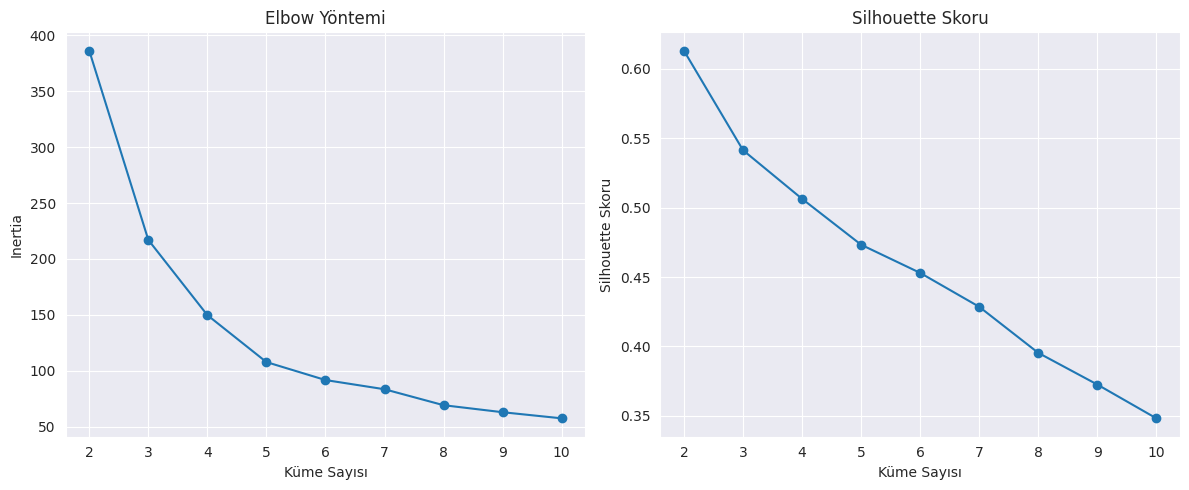

Optimal küme sayısı (Silhouette ile): 3


In [19]:
# --------------------
# 7. Elbow ve Silhouette Analizi (KMeans için)
# --------------------
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

# Elbow Grafiği
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Yöntemi')
plt.xlabel('Küme Sayısı')
plt.ylabel('Inertia')

# Silhouette Grafiği
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Skoru')
plt.xlabel('Küme Sayısı')
plt.ylabel('Silhouette Skoru')
plt.tight_layout()
plt.show()

optimal_k = k_range[np.argmax(silhouette_scores)]
optimal_k = 3
print("Optimal küme sayısı (Silhouette ile):", optimal_k)

In [20]:
# --------------------
# 8. Kümeleme Algoritmaları ve Silhouette Skorları
# --------------------
results = {}

# --- KMeans
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)
kmeans_score = silhouette_score(X_pca, kmeans_labels)
results['KMeans'] = kmeans_score

# --- DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)
dbscan_score = silhouette_score(X_pca, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1
results['DBSCAN'] = dbscan_score

# --- Agglomerative
agg = AgglomerativeClustering(n_clusters=optimal_k)
agg_labels = agg.fit_predict(X_pca)
agg_score = silhouette_score(X_pca, agg_labels)
results['Agglomerative'] = agg_score


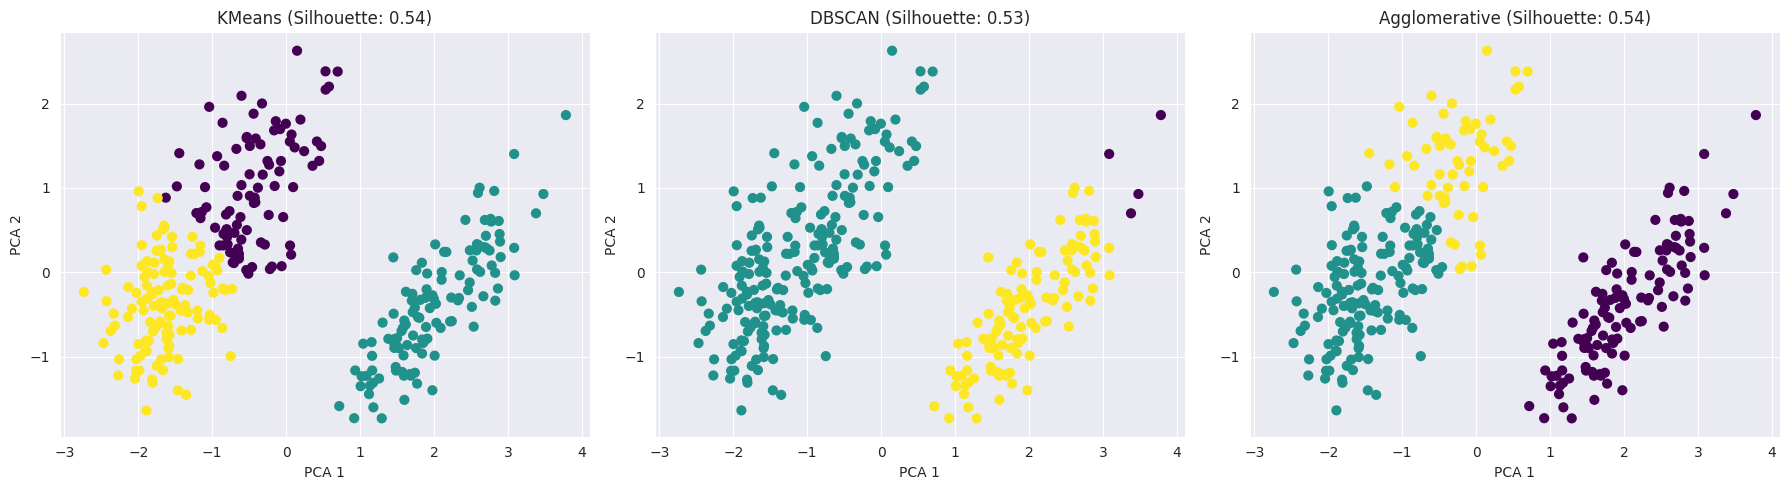

In [21]:
# --------------------
# 9. Kümeleme Sonuçlarının Görselleştirilmesi (PCA)
# --------------------
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for ax, labels, title in zip(axs, [kmeans_labels, dbscan_labels, agg_labels], results.keys()):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=40)
    ax.set_title(f"{title} (Silhouette: {results[title]:.2f})")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")

plt.tight_layout()
plt.show()

In [22]:
# --------------------
# 10. Kümeleme Skorlarının Özeti
# --------------------
print("Silhouette Skorları:")
for model, score in results.items():
    print(f"{model}: {score:.4f}")

Silhouette Skorları:
KMeans: 0.5414
DBSCAN: 0.5302
Agglomerative: 0.5399
